# 04 - Pengujian End-to-End Sistem per Format Input

Notebook ini menguji **pipeline lengkap** sistem peringkasan rapat secara end-to-end:

```
Input File → Transkripsi (Whisper) → Filter Kata Kasar → Peringkasan (IndoT5) → Evaluasi ROUGE
```

Pengujian dipisahkan berdasarkan **format input** (MP4, MP3, WAV) untuk membandingkan:
1. **Waktu proses** di setiap tahap pipeline
2. **Skor ROUGE** hasil ringkasan per format
3. **Konsistensi output** antar format input

In [1]:
import pandas as pd
from pathlib import Path

print("⏳ Menyatukan kepingan puzzle ringkasan manual...")

# Load file dataset test lo yang ada target manualnya
path_dataset = Path('../dataset/data_segment_siap_anotasi.csv')
df_anotasi = pd.read_csv(path_dataset)

# Pastikan teksnya dibaca sebagai string
df_anotasi['target_summary_manual'] = df_anotasi['target_summary_manual'].fillna('').astype(str)

# Gabungin target manual per video rapat
df_e2e_ref = df_anotasi.groupby('dokumen_asal', sort=False).agg(
    referensi_ringkasan=('target_summary_manual', lambda x: ' '.join(x)),
    jumlah_segmen=('dokumen_asal', 'count')
).reset_index()

# Simpan ke CSV
out_path = Path('../dataset/end_to_end_test_reference.csv')
df_e2e_ref.to_csv(out_path, index=False, encoding='utf-8')

print(f"✅ File '{out_path.name}' berhasil dibuat! Total: {len(df_e2e_ref)} dokumen utuh.")
display(df_e2e_ref.head(2))

⏳ Menyatukan kepingan puzzle ringkasan manual...
✅ File 'end_to_end_test_reference.csv' berhasil dibuat! Total: 30 dokumen utuh.


,dokumen_asal,referensi_ringkasan,jumlah_segmen
0,Paripurna_Ke_10_Persidangan_II_2024_2025,Rapat Paripurna DPR RI menyetujui agenda Pidat...,10
1,Paripurna_Ke_11_Persidangan_II_2024_2025,Rapat Paripurna DPR RI menyetujui agenda pengu...,2


## 1. Import & Setup

In [2]:
import os
import sys
import time
import pandas as pd
import evaluate
import torch
import matplotlib.pyplot as plt
from pathlib import Path

ffmpeg_dir = r"C:\Users\User\AppData\Local\Microsoft\WinGet\Packages"
for root, dirs, files in os.walk(ffmpeg_dir):
    if "ffmpeg.exe" in files:
        os.environ["PATH"] = root + ";" + os.environ["PATH"]
        print(f"FFmpeg ditemukan: {root}")
        break

sys.path.append('..')
from modules.transcriber import transcribe_audio, WHISPER_MODEL, WHISPER_LANGUAGE
from modules.filter_kata import filter_teks
from modules.summarizer import summarize_text

print(f"Whisper model: {WHISPER_MODEL}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FFmpeg ditemukan: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin
Whisper model: medium
Device: cpu


## 2. Konfigurasi File Uji

Menggunakan file referensi khusus end-to-end (`end_to_end_test_reference.csv`) yang berisi ringkasan gabungan per dokumen utuh.

In [3]:
# Load referensi end-to-end (ringkasan gabungan per dokumen utuh)
df_ref = pd.read_csv('../dataset/end_to_end_test_reference.csv')

# =========================================================
# PERBAIKAN: Tambahkan [:1] untuk testing 1 file aja
# =========================================================
# SAMPLE_FILES = df_ref['dokumen_asal'].tolist()[:1] 
SAMPLE_FILES = ['Paripurna_Ke_11_Persidangan_II_2024_2025']

print(f"Referensi end-to-end di CSV: {len(df_ref)} dokumen")
print(f"🚨 SEDANG MENGUJI {len(SAMPLE_FILES)} FILE SAJA BIAR CEPAT 🚨")

# Filter tabel untuk ditampilin
df_tampil = df_ref[df_ref['dokumen_asal'].isin(SAMPLE_FILES)]
display(df_tampil[['dokumen_asal', 'jumlah_segmen']])

# Direktori sumber
DIR_MP4 = Path('../dataset/01_raw/video_mp4')
DIR_MP3 = Path('../dataset/01_raw/audio_mp3')
DIR_WAV = Path('../dataset/01_raw/audio_wav')

# Format dan direktori
FORMAT_MAP = {
    'MP4': (DIR_MP4, '.mp4'),
    'MP3': (DIR_MP3, '.mp3'),
    'WAV': (DIR_WAV, '.wav'),
}

# Validasi keberadaan file
print("\nValidasi file uji:")
for name in SAMPLE_FILES:
    for fmt, (dir_path, ext) in FORMAT_MAP.items():
        fp = dir_path / (name + ext)
        status = '✅' if fp.exists() else '❌'
        print(f"  {status} {fmt}: {fp.name}")

Referensi end-to-end di CSV: 30 dokumen
🚨 SEDANG MENGUJI 1 FILE SAJA BIAR CEPAT 🚨


,dokumen_asal,jumlah_segmen
1,Paripurna_Ke_11_Persidangan_II_2024_2025,2



Validasi file uji:
  ✅ MP4: Paripurna_Ke_11_Persidangan_II_2024_2025.mp4
  ✅ MP3: Paripurna_Ke_11_Persidangan_II_2024_2025.mp3
  ✅ WAV: Paripurna_Ke_11_Persidangan_II_2024_2025.wav


## 3. Fungsi Pipeline End-to-End

Menjalankan seluruh tahapan dan mencatat waktu per tahap.

In [4]:
def pipeline_end_to_end(file_path: Path, fmt_label: str) -> dict:
    """
    Jalankan pipeline lengkap untuk satu file:
      1. Transkripsi (Whisper)
      2. Filter kata kasar
      3. Peringkasan (IndoT5)
    """
    hasil = {
        'file': file_path.stem,
        'format': fmt_label,
    }
    
    # ── Tahap 1: Transkripsi Whisper ──
    print(f"    🔊 Tahap 1: Transkripsi Whisper...")
    t0 = time.time()
    teks_transkrip = transcribe_audio(
        file_path,
        model_name=WHISPER_MODEL,
        language=WHISPER_LANGUAGE,
    )
    hasil['waktu_transkripsi'] = round(time.time() - t0, 2)
    hasil['jumlah_kata_transkrip'] = len(teks_transkrip.split())
    print(f"      ✅ {hasil['waktu_transkripsi']}s | {hasil['jumlah_kata_transkrip']} kata")
    
    # ── Tahap 2: Filter Kata Kasar ──
    print(f"    🧹 Tahap 2: Filter kata kasar...")
    t0 = time.time()
    teks_bersih = filter_teks(teks_transkrip, hapus=True)
    hasil['waktu_filter'] = round(time.time() - t0, 4)
    hasil['jumlah_kata_bersih'] = len(teks_bersih.split())
    kata_difilter = hasil['jumlah_kata_transkrip'] - hasil['jumlah_kata_bersih']
    print(f"      ✅ {hasil['waktu_filter']}s | {kata_difilter} kata difilter")
    
    # ── Tahap 3: Peringkasan IndoT5 ──
    print(f"    📝 Tahap 3: Peringkasan IndoT5...")
    t0 = time.time()
    ringkasan = summarize_text(teks_bersih)
    hasil['waktu_ringkasan'] = round(time.time() - t0, 2)
    hasil['jumlah_kata_ringkasan'] = len(ringkasan.split())
    print(f"      ✅ {hasil['waktu_ringkasan']}s | {hasil['jumlah_kata_ringkasan']} kata ringkasan")
    
    # ── Total ──
    hasil['waktu_total'] = round(
        hasil['waktu_transkripsi'] + hasil['waktu_filter'] + hasil['waktu_ringkasan'], 2
    )
    hasil['teks_transkrip'] = teks_transkrip
    hasil['teks_bersih'] = teks_bersih
    hasil['ringkasan'] = ringkasan
    
    return hasil

print("✅ Fungsi pipeline_end_to_end siap.")

✅ Fungsi pipeline_end_to_end siap.


## 4. Jalankan Pengujian End-to-End

Pipeline dijalankan untuk setiap file uji × setiap format input.

In [5]:
semua_hasil = []

total_tes = len(SAMPLE_FILES) * len(FORMAT_MAP)
counter = 0

for name in SAMPLE_FILES:
    print(f"\n{'='*60}")
    print(f"📄 FILE: {name}")
    print(f"{'='*60}")
    
    for fmt_label, (dir_path, ext) in FORMAT_MAP.items():
        counter += 1
        file_path = dir_path / (name + ext)
        
        if not file_path.exists():
            print(f"\n  ⚠️ [{counter}/{total_tes}] {fmt_label}: File tidak ditemukan, SKIP")
            continue
        
        print(f"\n  🔄 [{counter}/{total_tes}] Format: {fmt_label}")
        
        try:
            hasil = pipeline_end_to_end(file_path, fmt_label)
            semua_hasil.append(hasil)
            print(f"    ⏱️ Total: {hasil['waktu_total']}s")
        except Exception as e:
            print(f"    ❌ ERROR: {e}")

print(f"\n\n{'='*60}")
print(f"✅ Selesai! {len(semua_hasil)}/{total_tes} pengujian berhasil.")
print(f"{'='*60}")


📄 FILE: Paripurna_Ke_11_Persidangan_II_2024_2025

  🔄 [1/3] Format: MP4
    🔊 Tahap 1: Transkripsi Whisper...


d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
 95%|█████████▍| 54501/57501 [06:31<00:21, 139.24frames/s]


      ✅ 401.49s | 726 kata
    🧹 Tahap 2: Filter kata kasar...
      ✅ 0.0007s | 0 kata difilter
    📝 Tahap 3: Peringkasan IndoT5...


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 677.91it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


      ✅ 42.1s | 162 kata ringkasan
    ⏱️ Total: 443.59s

  🔄 [2/3] Format: MP3
    🔊 Tahap 1: Transkripsi Whisper...


 95%|█████████▍| 54500/57500 [06:20<00:20, 143.20frames/s]


      ✅ 381.45s | 687 kata
    🧹 Tahap 2: Filter kata kasar...
      ✅ 0.0008s | 0 kata difilter
    📝 Tahap 3: Peringkasan IndoT5...
      ✅ 34.21s | 140 kata ringkasan
    ⏱️ Total: 415.66s

  🔄 [3/3] Format: WAV
    🔊 Tahap 1: Transkripsi Whisper...


 95%|█████████▍| 54500/57500 [06:35<00:21, 137.81frames/s]


      ✅ 395.84s | 726 kata
    🧹 Tahap 2: Filter kata kasar...
      ✅ 0.0009s | 0 kata difilter
    📝 Tahap 3: Peringkasan IndoT5...
      ✅ 32.58s | 162 kata ringkasan
    ⏱️ Total: 428.42s


✅ Selesai! 3/3 pengujian berhasil.


## 5. Tabel Perbandingan Waktu per Tahap dan Format

In [6]:
# Buat DataFrame hasil
df_hasil = pd.DataFrame(semua_hasil)

# Tabel detail per file
kolom_tampil = ['file', 'format', 'waktu_transkripsi', 'waktu_filter', 
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan']
print("📋 DETAIL HASIL PER FILE DAN FORMAT")
print("=" * 60)
display(df_hasil[kolom_tampil])

# Rata-rata waktu per format
print("\n📊 RATA-RATA WAKTU PER FORMAT INPUT")
print("=" * 60)
df_avg = df_hasil.groupby('format')[[
    'waktu_transkripsi', 'waktu_filter', 'waktu_ringkasan', 'waktu_total'
]].mean().round(2)
display(df_avg)

📋 DETAIL HASIL PER FILE DAN FORMAT


,file,format,waktu_transkripsi,waktu_filter,waktu_ringkasan,waktu_total,jumlah_kata_transkrip,jumlah_kata_bersih,jumlah_kata_ringkasan
0,Paripurna_Ke_11_Persidangan_II_2024_2025,MP4,401.49,0.0007,42.10,443.59,726,726,162
1,Paripurna_Ke_11_Persidangan_II_2024_2025,MP3,381.45,0.0008,34.21,415.66,687,687,140
2,Paripurna_Ke_11_Persidangan_II_2024_2025,WAV,395.84,0.0009,32.58,428.42,726,726,162



📊 RATA-RATA WAKTU PER FORMAT INPUT


,waktu_transkripsi,waktu_filter,waktu_ringkasan,waktu_total
format,,,,
MP3,381.45,0.0,34.21,415.66
MP4,401.49,0.0,42.10,443.59
WAV,395.84,0.0,32.58,428.42


## 6. Evaluasi ROUGE per Format Input

Membandingkan ringkasan pipeline end-to-end dengan referensi gabungan di `end_to_end_test_reference.csv`.

In [7]:
rouge = evaluate.load('rouge')

# Untuk setiap format, bandingkan ringkasan dengan referensi end-to-end
rouge_per_format = {}

for fmt_label in FORMAT_MAP.keys():
    hasil_fmt = [h for h in semua_hasil if h['format'] == fmt_label]
    if not hasil_fmt:
        continue
    
    preds_fmt = []
    refs_fmt = []
    
    for h in hasil_fmt:
        file_name = h['file']
        ref_row = df_ref[df_ref['dokumen_asal'] == file_name]
        
        if len(ref_row) > 0:
            preds_fmt.append(h['ringkasan'])
            refs_fmt.append(ref_row.iloc[0]['referensi_ringkasan'])
    
    if preds_fmt:
        scores = rouge.compute(predictions=preds_fmt, references=refs_fmt)
        rouge_per_format[fmt_label] = scores

# Tampilkan hasil ROUGE
print("📊 SKOR ROUGE PER FORMAT INPUT")
print("=" * 60)

rouge_rows = []
for fmt, scores in rouge_per_format.items():
    row = {'Format': fmt}
    for metric, value in scores.items():
        row[metric] = round(value, 4)
    rouge_rows.append(row)

df_rouge = pd.DataFrame(rouge_rows)
display(df_rouge)

📊 SKOR ROUGE PER FORMAT INPUT


,Format,rouge1,rouge2,rougeL,rougeLsum
0,MP4,0.3344,0.1616,0.1605,0.1605
1,MP3,0.2518,0.0725,0.1511,0.1511
2,WAV,0.3344,0.1616,0.1605,0.1605


## 7. Visualisasi Perbandingan

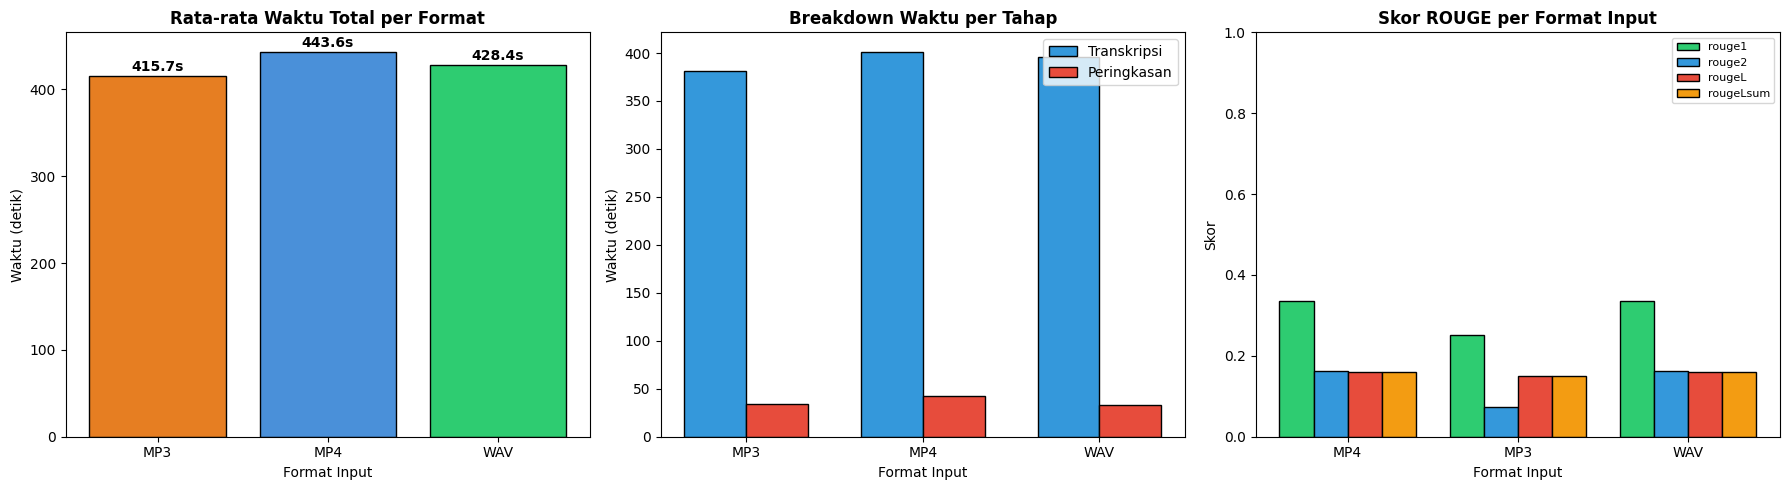

✅ Grafik disimpan ke dataset/end_to_end_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'MP4': '#4A90D9', 'MP3': '#E67E22', 'WAV': '#2ECC71'}

# ── Grafik 1: Rata-rata Waktu Total per Format ──
ax1 = axes[0]
avg_total = df_hasil.groupby('format')['waktu_total'].mean()
bars1 = ax1.bar(avg_total.index, avg_total.values, 
                color=[colors[f] for f in avg_total.index], edgecolor='black')
ax1.set_title('Rata-rata Waktu Total per Format', fontsize=12, fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_xlabel('Format Input')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}s',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Grafik 2: Breakdown Waktu per Tahap ──
ax2 = axes[1]
tahap_cols = ['waktu_transkripsi', 'waktu_ringkasan']
df_breakdown = df_hasil.groupby('format')[tahap_cols].mean()

x_pos = range(len(df_breakdown.index))
width = 0.35
bars_t = ax2.bar([p - width/2 for p in x_pos], df_breakdown['waktu_transkripsi'], 
                  width, label='Transkripsi', color='#3498DB', edgecolor='black')
bars_s = ax2.bar([p + width/2 for p in x_pos], df_breakdown['waktu_ringkasan'],
                  width, label='Peringkasan', color='#E74C3C', edgecolor='black')
ax2.set_title('Breakdown Waktu per Tahap', fontsize=12, fontweight='bold')
ax2.set_ylabel('Waktu (detik)')
ax2.set_xlabel('Format Input')
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(df_breakdown.index)
ax2.legend()

# ── Grafik 3: Skor ROUGE per Format ──
ax3 = axes[2]
if len(df_rouge) > 0:
    rouge_metrics = [c for c in df_rouge.columns if c != 'Format']
    x_pos3 = range(len(df_rouge))
    n_metrics = len(rouge_metrics)
    w = 0.8 / n_metrics
    
    metric_colors = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12']
    for i, metric in enumerate(rouge_metrics):
        offset = (i - n_metrics/2 + 0.5) * w
        bars_r = ax3.bar([p + offset for p in x_pos3], df_rouge[metric],
                         w, label=metric, color=metric_colors[i % len(metric_colors)],
                         edgecolor='black')
    
    ax3.set_title('Skor ROUGE per Format Input', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Skor')
    ax3.set_xlabel('Format Input')
    ax3.set_xticks(list(x_pos3))
    ax3.set_xticklabels(df_rouge['Format'])
    ax3.legend(fontsize=8)
    ax3.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('../dataset/end_to_end_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan ke dataset/end_to_end_comparison.png")

## 8. Perbandingan Konsistensi Output Antar Format

Cek apakah hasil transkripsi dan ringkasan konsisten meskipun format input berbeda.

In [9]:
# Bandingkan konsistensi antar format untuk file yang sama
rouge_konsistensi = evaluate.load('rouge')

print("📊 KONSISTENSI TRANSKRIPSI ANTAR FORMAT")
print("=" * 60)

for name in SAMPLE_FILES:
    hasil_file = {h['format']: h for h in semua_hasil if h['file'] == name}
    formats_tersedia = list(hasil_file.keys())
    
    if len(formats_tersedia) < 2:
        continue
    
    print(f"\n📄 {name}:")
    
    # Bandingkan transkripsi WAV vs format lain (WAV sebagai baseline)
    if 'WAV' in hasil_file:
        baseline = hasil_file['WAV']['teks_transkrip']
        for fmt in ['MP4', 'MP3']:
            if fmt in hasil_file:
                other = hasil_file[fmt]['teks_transkrip']
                score = rouge_konsistensi.compute(
                    predictions=[other], references=[baseline]
                )
                print(f"  WAV vs {fmt} (transkripsi): "
                      f"ROUGE-1={score['rouge1']:.4f} | "
                      f"ROUGE-L={score['rougeL']:.4f}")
    
    # Bandingkan ringkasan
    if 'WAV' in hasil_file:
        baseline_ring = hasil_file['WAV']['ringkasan']
        for fmt in ['MP4', 'MP3']:
            if fmt in hasil_file:
                other_ring = hasil_file[fmt]['ringkasan']
                score_ring = rouge_konsistensi.compute(
                    predictions=[other_ring], references=[baseline_ring]
                )
                print(f"  WAV vs {fmt} (ringkasan) : "
                      f"ROUGE-1={score_ring['rouge1']:.4f} | "
                      f"ROUGE-L={score_ring['rougeL']:.4f}")

📊 KONSISTENSI TRANSKRIPSI ANTAR FORMAT

📄 Paripurna_Ke_11_Persidangan_II_2024_2025:
  WAV vs MP4 (transkripsi): ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (transkripsi): ROUGE-1=0.9157 | ROUGE-L=0.9130
  WAV vs MP4 (ringkasan) : ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (ringkasan) : ROUGE-1=0.4821 | ROUGE-L=0.3192


## 9. Ringkasan Hasil Pengujian

In [10]:
print("\n" + "=" * 60)
print("  RINGKASAN PENGUJIAN END-TO-END")
print("=" * 60)

print(f"\n📂 Jumlah file diuji  : {len(SAMPLE_FILES)}")
print(f"🔄 Format diuji       : {', '.join(FORMAT_MAP.keys())}")
print(f"✅ Total pengujian    : {len(semua_hasil)}")

# Waktu rata-rata
print(f"\n⏱️ RATA-RATA WAKTU (detik):")
print("-" * 50)
for fmt in FORMAT_MAP.keys():
    data_fmt = [h for h in semua_hasil if h['format'] == fmt]
    if data_fmt:
        avg_transkrip = sum(h['waktu_transkripsi'] for h in data_fmt) / len(data_fmt)
        avg_filter = sum(h['waktu_filter'] for h in data_fmt) / len(data_fmt)
        avg_ringkas = sum(h['waktu_ringkasan'] for h in data_fmt) / len(data_fmt)
        avg_total = sum(h['waktu_total'] for h in data_fmt) / len(data_fmt)
        print(f"  {fmt}: Transkripsi={avg_transkrip:.1f}s | "
              f"Filter={avg_filter:.4f}s | "
              f"Ringkasan={avg_ringkas:.1f}s | "
              f"Total={avg_total:.1f}s")

# ROUGE
print(f"\n📊 SKOR ROUGE:")
print("-" * 50)
for fmt, scores in rouge_per_format.items():
    r1 = scores.get('rouge1', 0)
    r2 = scores.get('rouge2', 0)
    rl = scores.get('rougeL', 0)
    print(f"  {fmt}: ROUGE-1={r1:.4f} | ROUGE-2={r2:.4f} | ROUGE-L={rl:.4f}")

print(f"\n{'='*60}")
print("  Pipeline: Input → Whisper → Filter Kata → IndoT5 → Output")
print(f"{'='*60}")


  RINGKASAN PENGUJIAN END-TO-END

📂 Jumlah file diuji  : 1
🔄 Format diuji       : MP4, MP3, WAV
✅ Total pengujian    : 3

⏱️ RATA-RATA WAKTU (detik):
--------------------------------------------------
  MP4: Transkripsi=401.5s | Filter=0.0007s | Ringkasan=42.1s | Total=443.6s
  MP3: Transkripsi=381.4s | Filter=0.0008s | Ringkasan=34.2s | Total=415.7s
  WAV: Transkripsi=395.8s | Filter=0.0009s | Ringkasan=32.6s | Total=428.4s

📊 SKOR ROUGE:
--------------------------------------------------
  MP4: ROUGE-1=0.3344 | ROUGE-2=0.1616 | ROUGE-L=0.1605
  MP3: ROUGE-1=0.2518 | ROUGE-2=0.0725 | ROUGE-L=0.1511
  WAV: ROUGE-1=0.3344 | ROUGE-2=0.1616 | ROUGE-L=0.1605

  Pipeline: Input → Whisper → Filter Kata → IndoT5 → Output


## 10. Simpan Hasil ke CSV

In [11]:
# Simpan hasil detail
kolom_simpan = ['file', 'format', 'waktu_transkripsi', 'waktu_filter',
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan',
                'teks_transkrip', 'teks_bersih', 'ringkasan']
df_simpan = df_hasil[kolom_simpan]
df_simpan.to_csv('../dataset/hasil_end_to_end_test.csv', index=False, encoding='utf-8')

# Simpan skor ROUGE
df_rouge.to_csv('../dataset/rouge_per_format.csv', index=False, encoding='utf-8')

print("✅ Hasil tersimpan:")
print("  📄 dataset/hasil_end_to_end_test.csv")
print("  📄 dataset/rouge_per_format.csv")
print("  📄 dataset/end_to_end_comparison.png")

✅ Hasil tersimpan:
  📄 dataset/hasil_end_to_end_test.csv
  📄 dataset/rouge_per_format.csv
  📄 dataset/end_to_end_comparison.png
